In [1]:
import os

os.chdir("../")
configs_file = "train_debug"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


from spinodal_decomp.configs import load_configs
configs = load_configs(configs_file).Configs()

# from corrosion2d.configs import Configs
# configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})


Text(0, 0.5, 'Loss')

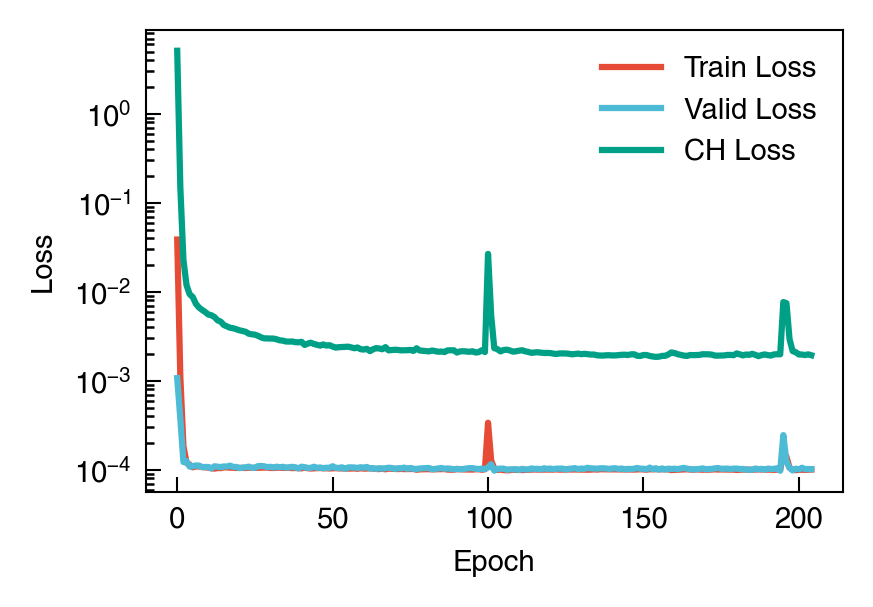

In [4]:
# read csv loss
import pandas as pd
save_dir = configs.save_dir
loss_df = pd.read_csv(os.path.join(save_dir, "logs.csv"))
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(loss_df["Epoch"], loss_df["TrainLoss"], label="Train Loss")
ax.plot(loss_df["Epoch"], loss_df["ValidLoss"], label="Valid Loss")

if configs.physical_residual:
    ax.plot(loss_df["Epoch"], loss_df["CHLoss"], label="CH Loss")
    
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

Text(0, 0.5, 'MSE')

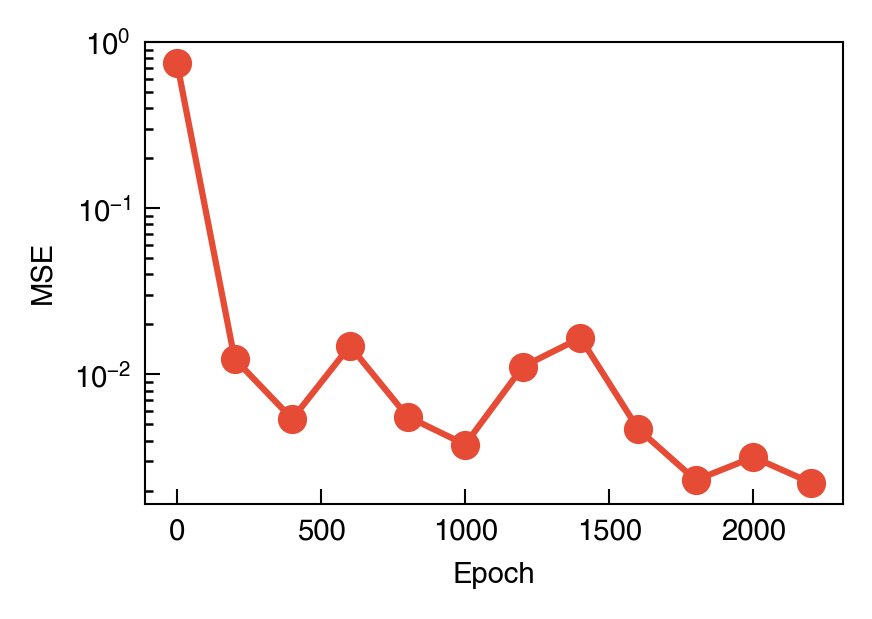

In [4]:
test_mse_df = pd.read_csv(os.path.join(save_dir, "test_logs.csv"))
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(test_mse_df["Epoch"], test_mse_df["TestMSE"], label="Test MSE", marker='o')
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")


In [13]:
# from model import model1d
from spinodal_decomp.model2d import get_model2d

model_kwargs = {
   'modes_x': configs.modes_x,
   'modes_y': configs.modes_x,
   'width': configs.width,
   'depth': configs.depth,
   'activation': getattr(jax.nn, configs.activation),
   'key': jax.random.PRNGKey(0),
}


model_skeleton = get_model2d(
   configs.model_type,
   configs.in_channels,
   configs.out_channels,
   **model_kwargs
)
# weight = os.path.join(save_dir, f"epoch_{configs.epochs - 1}.eqx")
weight = os.path.join(save_dir, f"epoch_2000.eqx")
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [14]:
# data = jnp.load("./dataset_split.npz")
data = jnp.load(os.path.join(configs.data_dir, "dataset_split.npz"))

# Xs, Ys = data["train_x"], data["train_y"]
Xs, Ys = data["valid_x"], data["valid_y"]
meshes = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["meshes"]
times = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["times"]
dt = times[1] - times[0]
meshesx = meshes[0]
meshesy = meshes[1]
Xs.shape, Ys.shape

((625, 3, 64, 64), (625, 1, 64, 64))

In [15]:
Xs[0, 1, ...]

array([[0.      , 0.015625, 0.03125 , ..., 0.953125, 0.96875 , 0.984375],
       [0.      , 0.015625, 0.03125 , ..., 0.953125, 0.96875 , 0.984375],
       [0.      , 0.015625, 0.03125 , ..., 0.953125, 0.96875 , 0.984375],
       ...,
       [0.      , 0.015625, 0.03125 , ..., 0.953125, 0.96875 , 0.984375],
       [0.      , 0.015625, 0.03125 , ..., 0.953125, 0.96875 , 0.984375],
       [0.      , 0.015625, 0.03125 , ..., 0.953125, 0.96875 , 0.984375]],
      shape=(64, 64))

MSE: 3.03586460859151e-07
MSE: 9.638202236317284e-09
MSE: 6.770581535420206e-07
MSE: 3.5848685797645885e-07


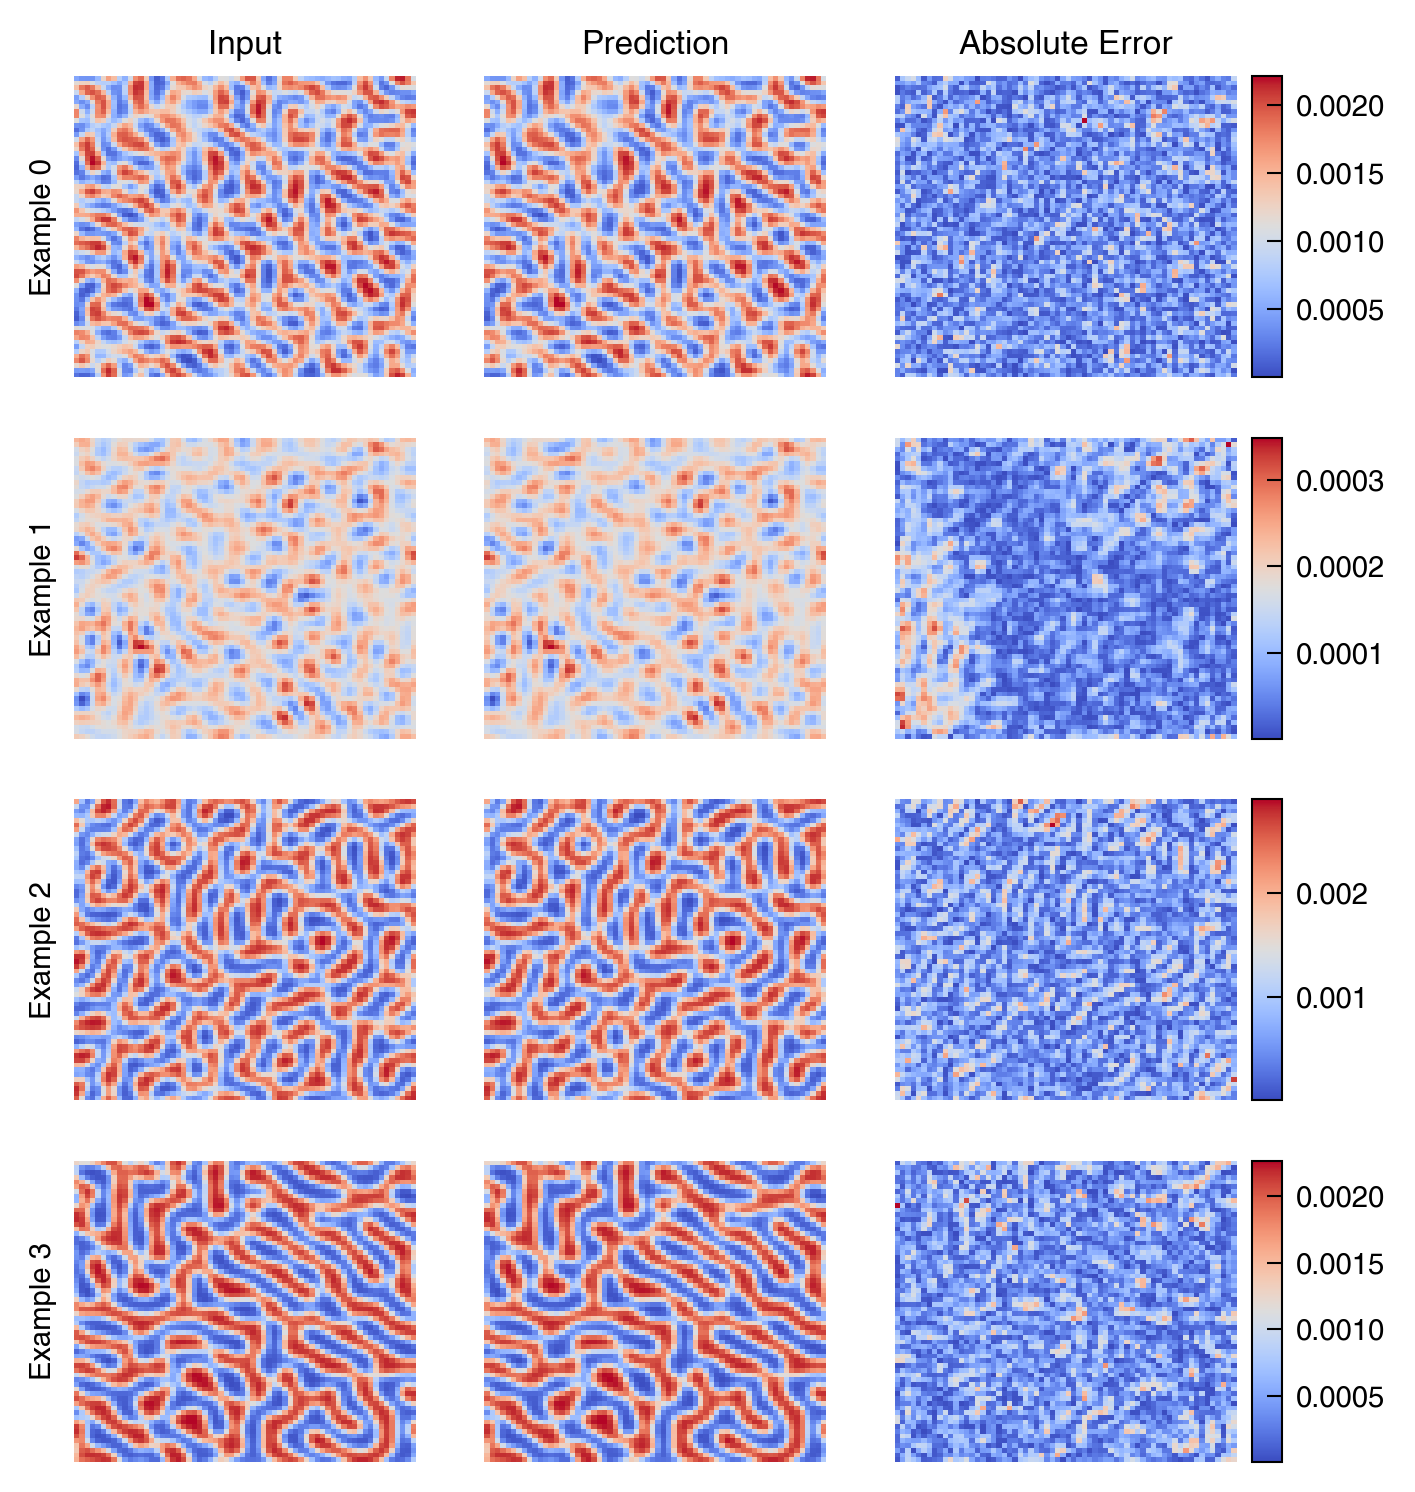

In [16]:
num_examples = 4
import numpy as np
# random_indices = np.random.choice(Xs.shape[0], num_examples, replace=False)
random_indices = [0, 1, 2, 3]
fig, axes = plt.subplots(num_examples, 3, figsize=(5, 1.5 * num_examples))
xs_examples = Xs[random_indices]
ys_examples = Ys[random_indices]
# ks_examples = ks[random_indices]
y_pred_examples = jax.vmap(model.forward)(xs_examples)
component = 0

for i, idx in enumerate(random_indices):
    ax = axes[i, 0]
    ax.pcolormesh(meshesx, meshesy, ys_examples[i, component, :, :], shading='auto', cmap='coolwarm',)
    ax.set_axis_off()
    # ax.set_ylabel(f"Example {idx}", rotation=0, labelpad=20, fontsize=8, va='center')
    ax.text(-0.05, 0.5, f"Example {idx}", rotation=90, va='center', ha="right", transform=ax.transAxes,)
    if i == 0:
        ax.text(0.5, 1.05, "Input", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax = axes[i, 1]
    ax.pcolormesh(meshesx, meshesy, y_pred_examples[i, component, :, :], shading='auto', cmap='coolwarm', )
    ax.set_axis_off()
    if i == 0:
        ax.text(0.5, 1.05, "Prediction", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax = axes[i, 2]
    diff = jnp.abs(ys_examples[i, component, :, :] - y_pred_examples[i, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=100, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    ax.set_axis_off()
    if i == 0:
        ax.text(0.5, 1.05, "Absolute Error", ha="center", va="bottom", transform=ax.transAxes, fontsize=8)

    ax_bar = fig.add_axes([ax.get_position().x1 + 0.01,
                           ax.get_position().y0,
                           0.02,
                           ax.get_position().height])
    fig.colorbar(diff_ax, cax=ax_bar)
    print(f"MSE: {jnp.mean(diff**2)}")
# fig.tight_layout()

In [17]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))
# test_solutions = jnp.load(os.path.join("/root/autodl-tmp/data/spinodal_decomp_spectra/test_extra", 
#                                        "solutions_grid.npy"))
start = 0
steps = 100
u0 = test_solutions[:, start, :, :]
y_test = test_solutions[:, start+1:start+1+steps, :, :]
auto_reg_fn = partial(
    model.auto_reg,
    meshes=meshes,
    steps=steps
)
u_preds = jax.vmap(auto_reg_fn, in_axes=(0,))(u0)

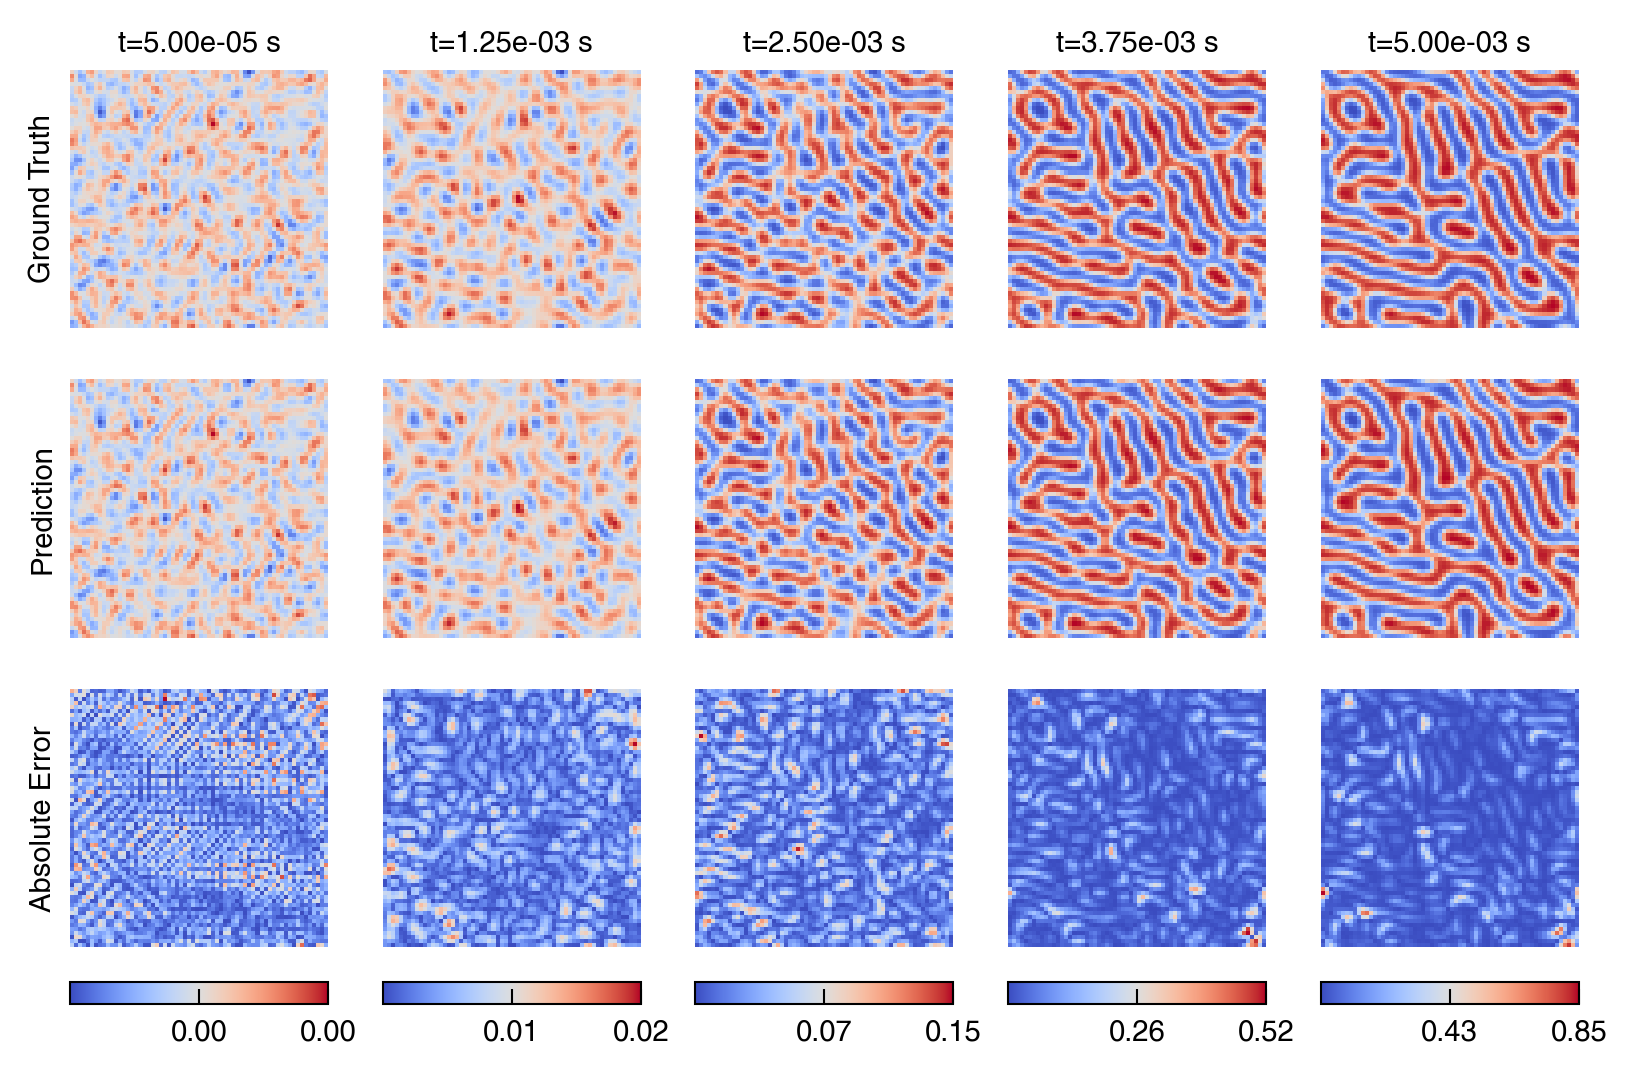

In [18]:
idxs = [0, 24, 49, 74, 99]
meshesx = meshes[0]
meshesy = meshes[1]
example_th = -1
component = 0
fig, axes = plt.subplots(3, len(idxs), figsize=(1.3 * len(idxs), 3.8),)
for i, idx in enumerate(idxs):
    ax = axes[0, i]
    # ax.contourf(meshesx, meshesy, y_test[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Ground Truth", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"t={(idx+1)*dt*configs.Tc:.2e} s", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    ax = axes[1, i]
    # ax.contourf(meshesx, meshesy, u_preds[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Prediction", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = axes[2, i]
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Absolute Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax_bar = fig.add_axes([ax.get_position().x0,
                           ax.get_position().y0 - 0.05,
                           ax.get_position().width,
                           0.02])
    
    # L2 = jnp.linalg.norm(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :]) / jnp.linalg.norm(y_test[example_th, idx, component, :, :])
    # # format as latex string wish scientific notation (\times 10^)
    # L2_magnitude = jnp.floor(jnp.log10(L2))
    # L2_coefficient = L2 / (10 ** L2_magnitude)
    # L2_text = r"$L_2=" + f"{L2_coefficient:.2f}" + r"\times 10^{" + f"{int(L2_magnitude)}" + "}$"
    # ax.text(0.01, 0.99, L2_text, ha="left", va="top", transform=ax.transAxes, fontsize=5, color='white')
    
    # fewer ticks on colorbar with 2 precision
    fig.colorbar(diff_ax, cax=ax_bar, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))

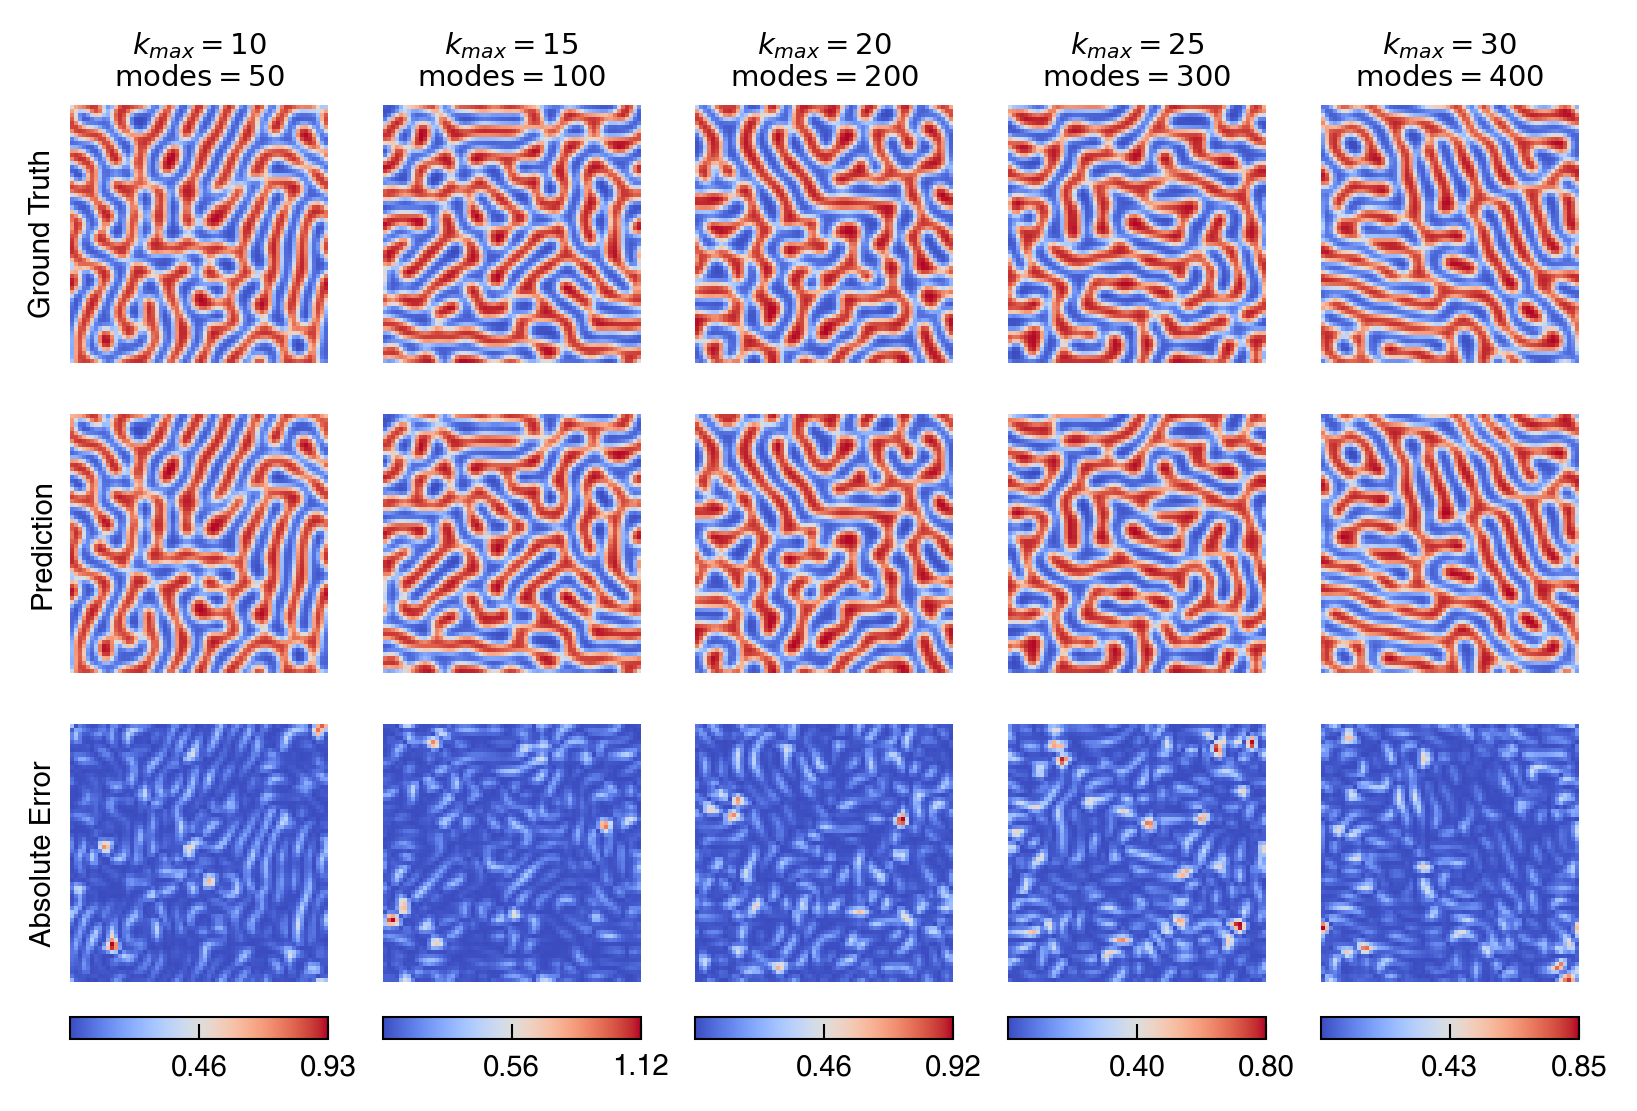

In [19]:
meshesx = meshes[0]
meshesy = meshes[1]
example_ths = [0,1,2,3,4]
modes = [50, 100, 200, 300, 400]
kmaxs = [10, 15, 20, 25, 30]
idx = -1
component = 0
fig, axes = plt.subplots(3, len(example_ths), figsize=(1.3 * len(example_ths), 3.8),)
for i, example_th in enumerate(example_ths):
    ax = axes[0, i]
    # ax.contourf(meshesx, meshesy, y_test[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Ground Truth", ha="right", va="center", transform=ax.transAxes, rotation=90)
    # ax.set_title(f"Ground Truth t={int((idx+1)*dt*configs.Tc)} s")
    ax.set_axis_off()
    ax.text(0.5, 1.05, fr"$k_{{max}}={kmaxs[i]}$" + "\n" + fr"$\text{{modes}}={modes[i]}$",
             ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    ax = axes[1, i]
    # ax.contourf(meshesx, meshesy, u_preds[example_th, idx, 0, :, :], levels=20, cmap='coolwarm')
    ax.pcolormesh(meshesx, meshesy, u_preds[example_th, idx, component, :, :], shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Prediction", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = axes[2, i]
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :])
    # diff_ax = ax.contourf(meshesx, meshesy, diff, levels=20, cmap='coolwarm')
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm')
    if i == 0:
        ax.text(-0.05, 0.5, "Absolute Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax_bar = fig.add_axes([ax.get_position().x0,
                           ax.get_position().y0 - 0.05,
                           ax.get_position().width,
                           0.02])
    
    # L2 = jnp.linalg.norm(y_test[example_th, idx, component, :, :] - u_preds[example_th, idx, component, :, :]) / jnp.linalg.norm(y_test[example_th, idx, component, :, :])
    # # format as latex string wish scientific notation (\times 10^)
    # L2_magnitude = jnp.floor(jnp.log10(L2))
    # L2_coefficient = L2 / (10 ** L2_magnitude)
    # L2_text = r"$L_2=" + f"{L2_coefficient:.2f}" + r"\times 10^{" + f"{int(L2_magnitude)}" + "}$"
    # ax.text(0.01, 0.99, L2_text, ha="left", va="top", transform=ax.transAxes, fontsize=5, color='white')
    
    # fewer ticks on colorbar with 2 precision
    fig.colorbar(diff_ax, cax=ax_bar, orientation='horizontal',
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3))

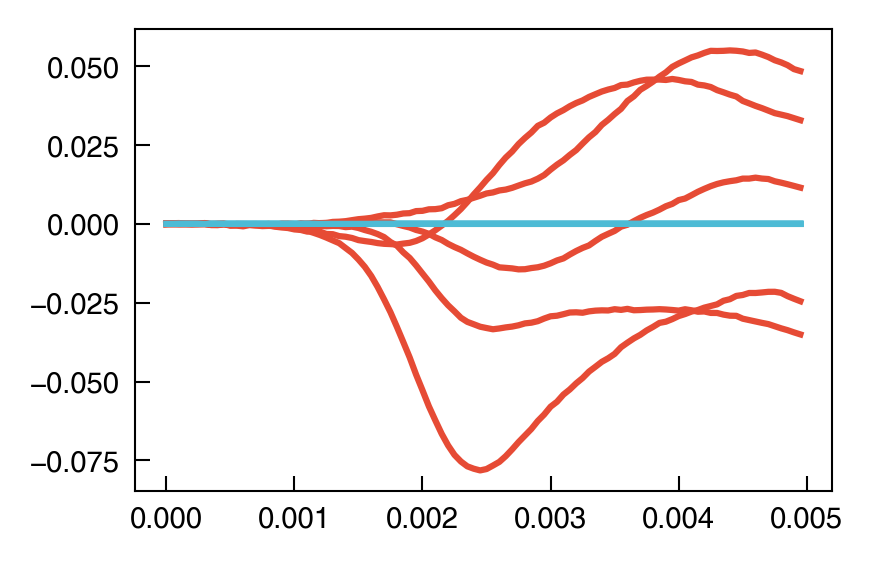

In [20]:
# conservation validation for c
component = 0
num_tests = y_test.shape[0]
mass = jnp.sum(y_test[:, :, component, :, :], axis=(-1, -2)) / (y_test.shape[2] * y_test.shape[3])
mass_pred = jnp.sum(u_preds[:, :, component, :, :], axis=(-1, -2)) / (y_test.shape[2] * y_test.shape[3])
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
time_points = jnp.arange(steps) * dt * configs.Tc
for i in range(num_tests):
    ax.plot(time_points, mass_pred[i, :], color='C0', )
    ax.plot(time_points, mass[i, :], color='C1',)

diff = jnp.mean(y_test - u_preds, axis=(-1,-2, -3))


In [ ]:
# acc logs
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))

u0 = test_solutions[:, 0, :, :]
y_test = test_solutions[:, 1:, :, :]
epochs = jnp.arange(0, 1001, 200)
mse_list = []
for epoch in epochs:
    weight = os.path.join(save_dir, f"epoch_{epoch}.eqx")
    model = eqx.tree_deserialise_leaves(weight, model_skeleton)

    auto_reg_fn = partial(
        model.auto_reg,
        meshes=meshes,
        steps=100
    )
    u_preds = jax.vmap(auto_reg_fn)(u0)

    mse = jnp.mean((y_test - u_preds) ** 2,)
    mse_list.append(mse)

TreePathError: Error at leaf with path (GetAttrKey(name='fno_blocks_de'), SequenceKey(idx=1), GetAttrKey(name='spectral_conv'), GetAttrKey(name='real_weights_neg'))

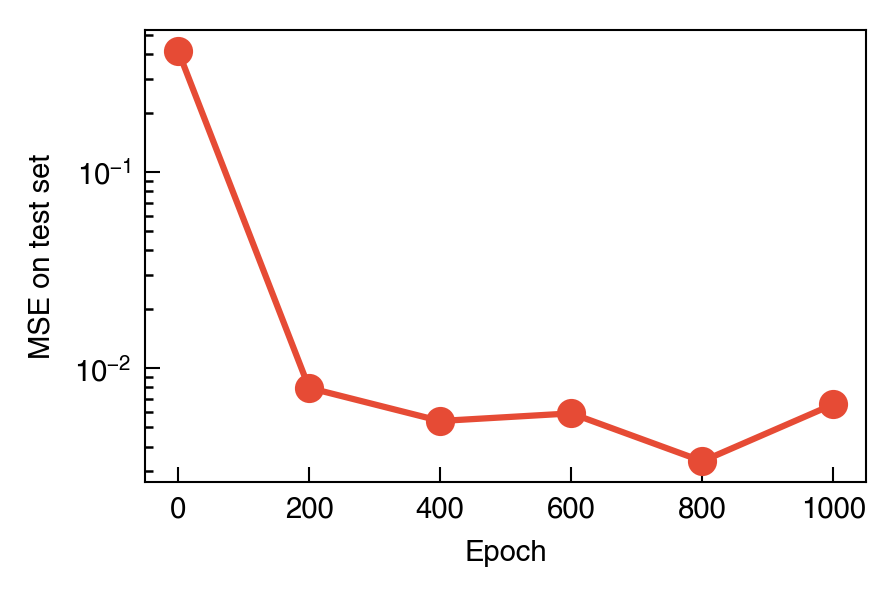

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
ax.plot(epochs, mse_list, marker='o')
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE on test set")
plt.tight_layout()

In [ ]:
# save test mse
path = os.path.join(save_dir, "test_mse.npy")
jnp.save(path, jnp.array(mse_list))

In [ ]:
l2 = jnp.linalg.norm(y_test - u_preds) / jnp.linalg.norm(y_test)
l2


Array(0.1785372, dtype=float32)

Text(0, 0.5, 'Relative $L_2$ Error')

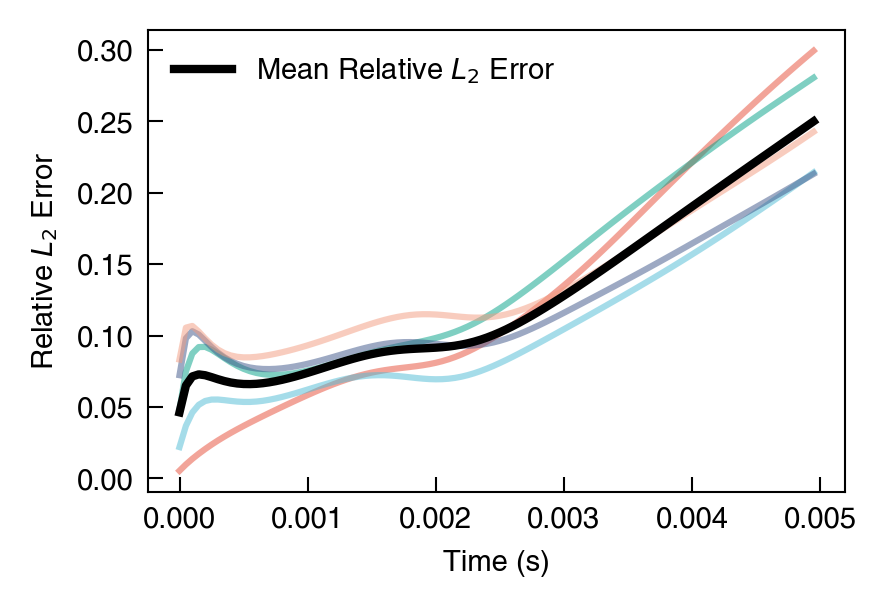

In [ ]:
# step-wise error


fig, ax = plt.subplots(1, 1, figsize=(3, 2))
time_points = jnp.arange(steps) * dt * configs.Tc
for i in range(y_test.shape[0]):
    step_pred = u_preds[i, :, 0, :, :]
    step_true = y_test[i, :, 0, :, :]
    step_error = jnp.linalg.norm(step_true - step_pred, axis=(-1,-2)) / jnp.linalg.norm(step_true, axis=(-1,-2))
    ax.plot(time_points, step_error, alpha=0.5)
mean_error = jnp.mean(jnp.linalg.norm(y_test - u_preds, axis=(-1,-2)) / jnp.linalg.norm(y_test, axis=(-1,-2)), axis=0)
ax.plot(time_points, mean_error, color='black', linewidth=2, label='Mean Relative $L_2$ Error')
ax.legend()
ax.set_xlabel("Time (s)")
ax.set_ylabel("Relative $L_2$ Error")

In [ ]:
y_test.shape

(5, 100, 1, 64, 64)

In [ ]:
jax.config.update("jax_enable_x64", False)

In [ ]:
nx = 64
ny = 64
lx = 1.0
ly = 1.0
dx = lx / nx
dy = ly / ny
kx = 2 * jnp.pi * jnp.fft.fftfreq(nx, d=dx).astype(jnp.float64)
ky = 2 * jnp.pi * jnp.fft.fftfreq(ny, d=dy).astype(jnp.float64)
KX, KY = jnp.meshgrid(kx, ky, indexing='xy') # indexing='xy' 对应 (ny, nx) 形状
K2 = KX**2 + KY**2
K4 = K2**2
K4.max()

/root/miniconda3/envs/jaxenv/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.


Array(6.5370143e+09, dtype=float32)

In [ ]:
xs_examples = xs_examples.astype(jnp.float64)
ys_examples = ys_examples.astype(jnp.float64)
y_pred_examples = y_pred_examples.astype(jnp.float64)
x0 = xs_examples[1]
c0 = x0[0, :, :]

pred = y_pred_examples[1]
c = pred[0, :, :]

print(c.shape, c0.shape)

# 重新获取原始 dt
dt =( times[1] - times[0]) * configs.Tc

# 计算控制方程残差 (Residual of Governing Equation)
# 方程: dc/dt = M * laplacian(mu)
# 采用半隐式格式: (c - c0)/dt = M * laplacian(f'(c0)) - M * lambda * bi-laplacian(c)

# 1. 转到频域
c0_hat = jnp.fft.fft2(c0)
c_hat = jnp.fft.fft2(c)

# 2. 计算 LHS: dc/dt
lhs_hat = (c_hat - c0_hat)

# 3. 计算 RHS: M * laplacian(f'(c0)) - M * lambda * bi-laplacian(c)
# 注意：laplacian -> -K2, bi-laplacian -> K4
M = 1.0
lambda_param = 0.01**2

f_prime = c0**3 - c0
f_prime_hat = jnp.fft.fft2(f_prime)

# M * laplacian(f'(c0)) -> M * (-K2) * f_prime_hat
term1_hat = -M * K2 * f_prime_hat * dt

# - M * lambda * bi-laplacian(c) -> - M * lambda * (K4) * c_hat
# 注意这里使用的是新时刻的 c (隐式项)
term2_hat = -M * lambda_param * K4 * c_hat * dt

rhs_hat = term1_hat + term2_hat

# 4. 计算残差 (LHS - RHS)
res_hat = lhs_hat - rhs_hat
residual = jnp.fft.ifft2(res_hat).real

# 打印统计
print(f"Residual Max: {jnp.max(jnp.abs(residual))}")
print(f"Residual Mean: {jnp.mean(jnp.abs(residual))}")
# 取绝对值用于后续绘图
residual = jnp.abs(residual)

(64, 64) (64, 64)
Residual Max: 0.0006159080658107996
Residual Mean: 0.00019807748321909457


In [ ]:
K4.max()

Array(6.5370143e+09, dtype=float32)